In [16]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="GD8tH6KEirCm0I5ySSBD")
# https://universe.roboflow.com/ai3-nrf8q/wildfire-8wuyh
project = rf.workspace("ai3-nrf8q").project("wildfire-8wuyh")
version = project.version(3)
dataset = version.download("yolo26")


loading Roboflow workspace...
loading Roboflow project...


In [17]:
!pip install ultralytics

In [18]:
import numpy as np

import torch
from torchvision.io import read_image

from ultralytics import YOLO

import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [19]:
def display_images(image_list=None, title=None, bboxes_list=None):
    if image_list is None:
        image_list = []

    if title is None:
        title = ""

    if bboxes_list is None:
        bboxes_list = []

    #(False, True)
    if not any(isinstance(i, list) for i in image_list):
        image_list = [image_list] #[img, img, img] => [[img, img, img]]

    rows = len(image_list)
    cols = max(len(row) if isinstance(row , list) else 1 for row in image_list)

    plt.suptitle(title)
    fig, ax = plt.subplots(rows, cols)

    #确保ax是2D数组
    #ax => [[ax]], [ax]=>[[ax]]
    ax = np.atleast_2d(ax)

    for i, row in enumerate(image_list):
        if not isinstance(row, list):
            row = [row]

        for j, img in enumerate(row):
            ax[i, j].imshow(img)
            ax[i, j].axis("off")

            bbox_index = i * cols + j
            if bbox_index < len(bboxes_list):
                for bbox in bboxes_list[bbox_index]:
                    x_min, y_min, x_max, y_max = bbox
                    width = x_max - x_min
                    height = y_max - y_min
                    rect = patches.Rectangle(
                        (x_min, y_min),
                        width,
                        height,
                        linewidth=2,
                        edgecolor="r",
                        facecolor="none"
                    )
                    ax[i, j].add_patch(rect)

        for j in range(len(row), cols):
            ax[i, j].axis("off")

    #plt.tight_layout()
    plt.show()

<Figure size 640x480 with 0 Axes>

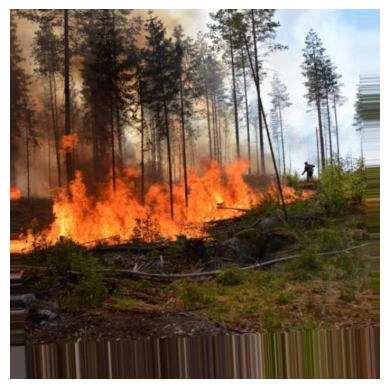

In [20]:
org_image_path = '/Users/guochaohe/projects/drones/tony-uav-bible/docs/ai-yolo/yolo26/Wildfire-3/train/images/wildfire_0_286_jpeg.rf.5fa186567d6c692c850520687ae9e5d0.jpg'
img = read_image(org_image_path)
display_images(img.permute(1,2,0))

In [21]:
MODEL_PATH = 'yolo26m.pt'
print("loading model....")
model = YOLO(MODEL_PATH)
print("yolo26 medium model loaded")

loading model....
yolo26 medium model loaded


In [22]:
results = model(org_image_path, device="mps")


image 1/1 /Users/guochaohe/projects/drones/tony-uav-bible/docs/ai-yolo/yolo26/Wildfire-3/train/images/wildfire_0_286_jpeg.rf.5fa186567d6c692c850520687ae9e5d0.jpg: 640x640 1 person, 39.9ms
Speed: 1.4ms preprocess, 39.9ms inference, 15.9ms postprocess per image at shape (1, 3, 640, 640)


<Figure size 640x480 with 0 Axes>

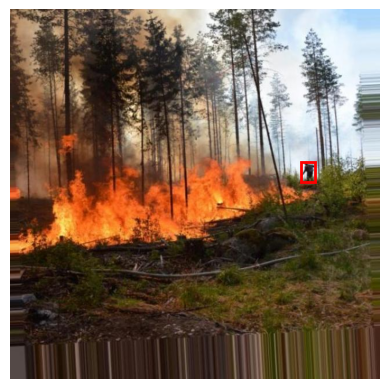

In [23]:
boxes = []
for result in results:
    xyxy = result.boxes.xyxy
    boxes.append(xyxy.cpu())

display_images(img.permute(1,2,0), bboxes_list=boxes)

In [24]:
training_data_path = "/Users/guochaohe/projects/drones/tony-uav-bible/docs/ai-yolo/yolo26/Wildfire-3/data.yaml"
model.train(data=training_data_path, epochs=100, imgsz=640, device="mps")

New https://pypi.org/project/ultralytics/8.4.138 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.117 🚀 Python-3.14.3 torch-2.13.0 MPS (Apple M4)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/guochaohe/projects/drones/tony-uav-bible/docs/ai-yolo/yolo26/Wildfire-3/data.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_

index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)


      1/100      18.8G      3.413      7.452    0.06016         44        640: 100% ━━━━━━━━━━━━ 24/24 8.2s/it 3:173.9ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 2.6s/it 10.2s.6sss
                   all        108        200   0.000269     0.0586   7.53e-05    1.5e-05

      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size


index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)


      2/100      18.8G      2.848      6.088     0.0484         41        640: 100% ━━━━━━━━━━━━ 24/24 5.9s/it 2:224.1ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 2.6s/it 10.4s.6sss
                   all        108        200   0.000716      0.136    0.00159   0.000327

      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size


...

index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)


     99/100      18.8G      1.379      1.498    0.02602         22        640: 100% ━━━━━━━━━━━━ 24/24 3.9s/it 1:333.5sss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 2.5s/it 9.9s4.4sss
                   all        108        200      0.344      0.204      0.213     0.0769

      Epoch    GPU_mem   box_loss   cls_loss    l1_loss  Instances       Size


index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)


    100/100      18.8G       1.41      1.497    0.02695         21        640: 100% ━━━━━━━━━━━━ 24/24 3.9s/it 1:333.5sss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 2.5s/it 9.9s4.5sss
                   all        108        200      0.276       0.21      0.212     0.0772

100 epochs completed in 3.335 hours.
Optimizer stripped from /Users/guochaohe/projects/drones/tony-uav-bible/docs/ai-yolo/yolo26/runs/detect/train/weights/last.pt, 44.0MB
Optimizer stripped from /Users/guochaohe/projects/drones/tony-uav-bible/docs/ai-yolo/yolo26/runs/detect/train/weights/best.pt, 44.0MB

Validating /Users/guochaohe/projects/drones/tony-uav-bible/docs/ai-yolo/yolo26/runs/detect/train/weights/best.pt...
Ultralytics 8.4.117 🚀 Python-3.14.3 torch-2.13.0 MPS (Apple M4)
YOLO26m summary (fused): 132 layers, 20,354,078 parameters, 0 gradients, 68.1 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-9

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x15f881f60>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

loading new model....
model new loaded

image 1/1 /Users/guochaohe/projects/drones/tony-uav-bible/docs/ai-yolo/yolo26/Wildfire-3/train/images/wildfire_0_286_jpeg.rf.5fa186567d6c692c850520687ae9e5d0.jpg: 640x640 2 wildfires, 35.5ms
Speed: 2.9ms preprocess, 35.5ms inference, 175.0ms postprocess per image at shape (1, 3, 640, 640)


<Figure size 640x480 with 0 Axes>

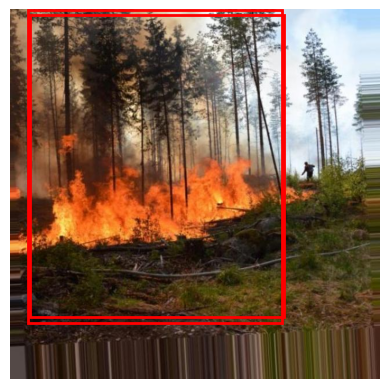

In [25]:
wildfire_model = '/Users/guochaohe/projects/drones/tony-uav-bible/docs/ai-yolo/yolo26/runs/detect/train/weights/best.pt'
print("loading new model....")
new_model = YOLO(wildfire_model)
print("model new loaded")

preds  = new_model(org_image_path, device="mps")
newboxes = []
for result in preds:
    xyxy = result.boxes.xyxy
    newboxes.append(xyxy.cpu())

display_images(img.permute(1,2,0), bboxes_list=newboxes)